# Disaster 'Risk' Assessment in Southeast Asia

---
Literature:

Delforge, D., Wathelet, V., Below, R., Sofia, C. L., Tonnelier, M., von Loenhout, J. A. F. and Speybroeck, N. (2025). EM-DAT: the Emergency Events Database. *International Journal of Disaster Risk Reduction, 124*, 1-17. https://doi.org/10.1016/j.ijdrr.2025.105509

Nakasu, T., Amrapala, C. (2023). Evidence-based disaster risk assessment in Southeast Asian countries. *Natural Hazards Research, 3*(2), 295-304. https://doi.org/10.1016/j.nhres.2023.04.001 

---

This notebook follows the methodology of Nakasu & Amrapala (2023) who analyze 'risk' and trends of natural disasters in Southeast Asia using data from EM-DAT. More specifically, we analyze which disaster types are associated with higher impact and how this changes when extending the time period or regions studied.

**Note**: Typically, (weather and climate) risk is defined as
$$\text{risk} = \text{probability} \times \text{severity},$$
where $\times$ is a convolution of distributions (not necessarily simple multiplication).
However, EM-DAT provides data on disasters that have already occurred, so, identifying future risk in the traditional sense is not possible (solely) with EM-DAT records, as they do not report the probability of future events. Nakasu & Amrapala (2023) therefore use the term "risk" in a retrospective sense, referring to past disasters. They define:
$$\text{risk} = \text{impact} + 2 \times \text{event count}$$
As to not confuse this 'retrospective risk' with the original definition of risk, we will use the term "risk" in quotation marks from now on, defining it as 
$$\text{"risk"} = \text{impact} + 2 \times \text{count},$$
where both, 'impact' and 'count' are standardized, as shown later. The three 'impact' variables we are interested in are `Total Damage`, `Total Deaths`, and `Total Affected`, which are summarized in the table in the data loading section.

## 0. Data Loading

The data file `se_asia.csv` contains all droughts, earthquakes (including tsunami), extreme temperature events, floods, landslides (dry and wet mass movements), storms, volcanic activities, and wildfires in Southeast Asia between 2000 and 2024 (inclusive) reported in EM-DAT (retrieved on March 18th from https://public.emdat.be). 

Southeast Asia includes the countries Brunei Darussalam, Cambodia, Indonesia, Lao People's Democratic Republic, Malaysia, Myanmar, Philippines, Singapore, Thailand, Timor-Leste, Vietnam. However, no events were reported for Brunei Darussalam and Singapore between 2000 and 2024. Hence, these two countries are excluded from the analysis. The variables of interest are summarized in the table below:


| Name                              | Type        | Description                                                                                                                | Source |
|-------------|-------------|-------------|-------------|
| Disaster Type | string | The disaster type. Options are 'Drought', 'Earthquake', 'Extreme temperature, 'Flood', 'Landslide', 'Storm', 'Volcanic activity' and 'Wildfire' | EM-DAT |
| Country | string | Country where the disaster occurred and had an impact using names from the UN M49 Standard | EM-DAT |
| Start Year | integer | Year of occurrence of the disaster | EM-DAT |
| Total Damage, Adjusted ('000 US$) | float | Total Damage (’000 US$) adjusted for inflation using the Consumer Price Index (CPI) | EM-DAT |
| Total Deaths | float | Total fatalities (deceased and missing combined) | EM-DAT |
| Total Affected | float | Total number of affected people (injured, homeless and/or affected) | EM-DAT |

We begin by loading the required modules and the data.

In [1]:
# Import modules
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Load data on natural disasters in Southeast Asia
se_asia = pd.read_csv("se_asia.csv")
se_asia = se_asia.rename(columns={"Total Damage, Adjusted ('000 US$)": "Total Damage"})
se_asia_2012 = se_asia[se_asia["Start Year"] >= 2012]
se_asia_2012.info()

<class 'pandas.core.frame.DataFrame'>
Index: 690 entries, 0 to 1159
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Disaster Subgroup  690 non-null    object 
 1   Disaster Type      690 non-null    object 
 2   Disaster Subtype   690 non-null    object 
 3   Country            690 non-null    object 
 4   Start Year         690 non-null    int64  
 5   Start Month        690 non-null    int64  
 6   Start Day          658 non-null    float64
 7   End Year           690 non-null    int64  
 8   End Month          690 non-null    float64
 9   End Day            659 non-null    float64
 10  Total Damage       264 non-null    float64
 11  Total Deaths       499 non-null    float64
 12  Total Affected     647 non-null    float64
dtypes: float64(6), int64(3), object(4)
memory usage: 75.5+ KB


## 1. Analysis of Disaster Type (2012-2024)

We begin with a "risk" analysis for different disaster types based on Nakasu & Amrapala (2023). Differently to Nakasu & Amrapala (2023), who consider disasters from 1990 to 2022, we first restrict ourselves to events between 2012 and 2024.

### 1.1 Proportion and Impact Shares of Disaster Types

Similarly as in Fig. 2 in Nakasu & Amrapala (2023), we plot the proportions of disaster types against the impact shares. The proportion of disaster type x is defined as
$$\text{Proportion of disaster x} = \frac{\text{number of disasters of type x}}{\text{total number of disasters}}$$
The shares of the three impact variables for each disaster type are defined in a similar manner. For example, the share of deaths of disaster type x is defined as
$$\text{Share of deaths of disaster x} = \frac{\text{deaths caused by disasters of type x}}{\text{total deaths}}$$
Before plotting these shares, we will:

1. Create the dataset `disaster_type` by grouping `se_asia_2012` by `Disaster Type`. Create the column `Count` that shows the absolute number of events for each disaster type. Aggregate the variables `Total Damage`, `Total Deaths` and `Total Affected` for each disaster type.
2. Calculate the proportion of disaster types and store it under the variable `Proportion`. Calculate impact shares for the disaster types for the variables `Total Damage`, `Total Deaths` and `Total Affected` and store them under `Damage_Share`, `Deaths_Share` and `Affected_Share`, respectively.

In [4]:
# Group the data se_asia_2012 by disaster type
disaster_type = (
    se_asia_2012.groupby("Disaster Type")
    .agg(
        Count=("Disaster Type", "size"),
        Total_Damage=("Total Damage", "sum"),
        Total_Deaths=("Total Deaths", "sum"),
        Total_Affected=("Total Affected", "sum")
    )
    .reset_index()
)

disaster_type["Proportion"] = 100 * disaster_type["Count"] / disaster_type["Count"].sum()
disaster_type = disaster_type.sort_values(by="Count", ascending=False)


# Calculate percentages for the four variables
disaster_type["Damage_Share"] = (
    100 * disaster_type["Total_Damage"] / disaster_type["Total_Damage"].sum()
)

disaster_type["Deaths_Share"] = (
    100 * disaster_type["Total_Deaths"] / disaster_type["Total_Deaths"].sum()
)

disaster_type["Affected_Share"] = (
    100 * disaster_type["Total_Affected"] / disaster_type["Total_Affected"].sum()
)

disaster_type = disaster_type.loc[:, 
                                  ['Disaster Type', 'Count', 'Proportion',
                                    'Total_Damage', 'Damage_Share',
                                    'Total_Deaths', 'Deaths_Share',
                                    'Total_Affected', 'Affected_Share']
                                  ]
disaster_type

,Disaster Type,Count,Proportion,Total_Damage,Damage_Share,Total_Deaths,Deaths_Share,Total_Affected,Affected_Share
3,Flood,329,47.681159,18733574.0,23.703036,3848.0,14.524591,50939615.0,20.566252
5,Storm,202,29.275362,40722131.0,51.524505,14499.0,54.727664,140293393.0,56.641758
1,Earthquake,65,9.420290,3948718.0,4.996196,5974.0,22.549353,11492121.0,4.639805
4,Landslide,44,6.376812,184421.0,0.233342,1357.0,5.122108,3617112.0,1.460365
6,Volcanic activity,25,3.623188,666366.0,0.843133,597.0,2.253425,1464166.0,0.591139
0,Drought,15,2.173913,13455796.0,17.025220,11.0,0.041520,38469245.0,15.531492
2,Extreme temperature,8,1.159420,0.0,0.000000,188.0,0.709621,1000134.0,0.403792
7,Wildfire,2,0.289855,1323487.0,1.674569,19.0,0.071717,409664.0,0.165397


### 1.2 Scatter Plot

In this section, a plot based on Fig. 2 in Nakasu & Amrapala (2023) is created. It consists of three subplots, which each plot the proportions of disaster types against one of the impact shares (deaths, affected, damages).

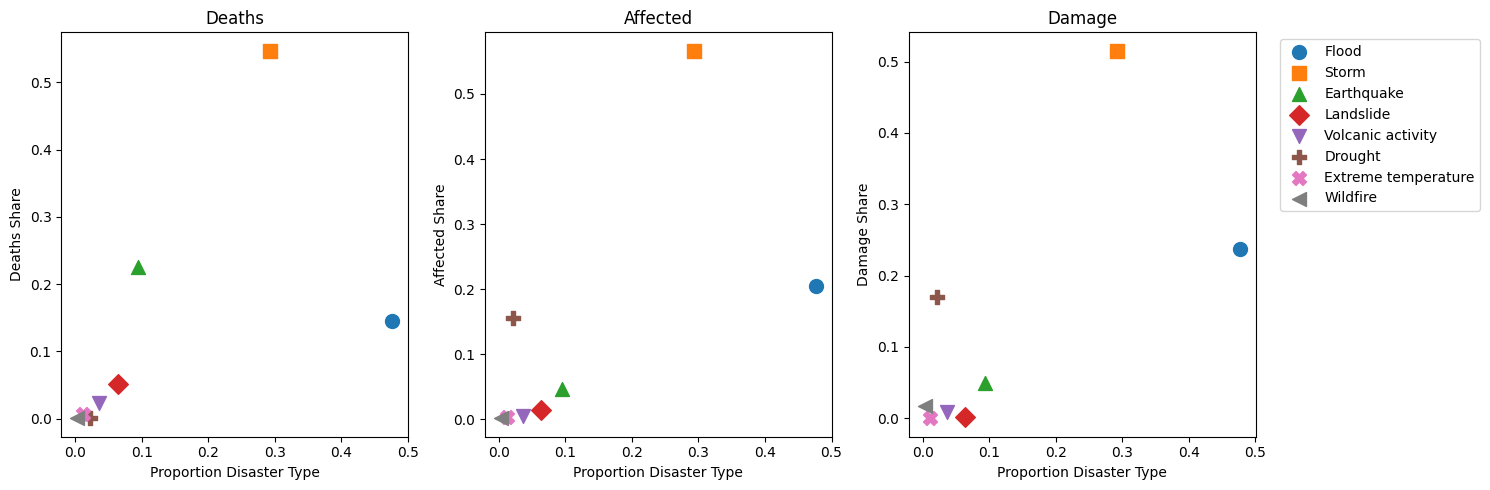

In [5]:
markers = ["o", "s", "^", "D", "v", "P", "X", "<"] # here, we define different symbols for the eight disaster types

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

y_vars = ["Deaths_Share", "Affected_Share", "Damage_Share"]
titles = ["Deaths", "Affected", "Damage"]


for i, ax in enumerate(axes):
    for j, (_, row) in enumerate(disaster_type.iterrows()):
        ax.scatter(
            row["Proportion"]/ 100,
            row[y_vars[i]]/ 100,
            marker=markers[j % len(markers)],
            s = 100,
            label=row["Disaster Type"]
        )
    
    ax.set_xlabel("Proportion Disaster Type")
    ax.set_ylabel(f"{titles[i]} Share")
    ax.set_title(titles[i])

axes[2].legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

Storms seem to be associated with the largest impact shares across all three impact variables - although floods make up the largest share of all reported events.

### 1.3 Standardization

Now, the count and impact variables are standardized so that they lie between 0 and 1. This allows us to later rank and classify the disaster types with respect to count and impact. We standardize the variables `Count`, `Total_Damage`, `Total_Deaths`, and `Total_Affected` in the dataset `disaster_type`, using this formula
$$x_{\text{std}} = \frac{x - \min(x)}{\max(x) - \min(x)}$$

In [6]:
disaster_type["Count_std"] = (
    (disaster_type["Count"] - disaster_type["Count"].min()) /
    (disaster_type["Count"].max() - disaster_type["Count"].min())
)

disaster_type["Damage_std"] = (
    (disaster_type["Total_Damage"] - disaster_type["Total_Damage"].min()) /
    (disaster_type["Total_Damage"].max() - disaster_type["Total_Damage"].min())
)

disaster_type["Deaths_std"] = (
    (disaster_type["Total_Deaths"] - disaster_type["Total_Deaths"].min()) /
    (disaster_type["Total_Deaths"].max() - disaster_type["Total_Deaths"].min())
)

disaster_type["Affected_std"] = (
    (disaster_type["Total_Affected"] - disaster_type["Total_Affected"].min()) /
    (disaster_type["Total_Affected"].max() - disaster_type["Total_Affected"].min())
)

### 1.4 "Risk" Identification

Now, we can classify the disaster types using the "risk" classification matrix in Figure 1 and the standardized count and impact variables. Based on the formula 
$$\text{"risk"} = \text{impact} + 2 \times \text{count},$$
where $\text{impact}$ and $\text{count}$ were standardized as in exercise 1.3, we can calculate a **"risk" score** that is then used to classify events based on the following scheme:
- "High": "risk" scores of 1-6 (red)
- "Relatively high": "risk" scores of 7-16 (yellow)
- "Moderate": "risk" scores of 17-25 (green)

As $\text{count}$ is multiplied by 2 in the "risk" formula, some cells are classified as *high* even if the $\text{count}$ is moderate (e.g., "risk" scores 3 and 5).

<img src="eval_matrix.png" width="500">

**Figure 1:** "Risk" classification matrix based on impact and event count.

In [7]:
print(disaster_type[["Disaster Type", "Count_std", "Deaths_std", "Affected_std", "Damage_std"]])

         Disaster Type  Count_std  Deaths_std  Affected_std  Damage_std
3                Flood   1.000000    0.264840      0.361228    0.460034
5                Storm   0.611621    1.000000      1.000000    1.000000
1           Earthquake   0.192661    0.411582      0.079226    0.096967
4            Landslide   0.128440    0.092904      0.022929    0.004529
6    Volcanic activity   0.070336    0.040447      0.007538    0.016364
0              Drought   0.039755    0.000000      0.272080    0.330430
2  Extreme temperature   0.018349    0.012217      0.004221    0.000000
7             Wildfire   0.000000    0.000552      0.000000    0.032500


The classification procedure works like this: For each disaster type and each impact variable, use the combination of `Count_std` and the standardized score of the impact variable to retrieve the "risk" score. For example, if `Count_std` = 1.0 and `Deaths_std` = 0.1 for floods, we assign a "risk" score of 19 to floods, classifying them as "moderate".

Classify each of the eight event types as high, relatively high or moderate for *any* impact variable of choice.

Impact variable: ________________
- Drought: ________________ 
- Earthquake: ________________
- Extreme temperature: ________________
- Flood: ________________
- Landslide: ________________
- Storm: ________________
- Volcanic activity: ________________
- Wildfire: ________________

## 2. Analysis of Disaster Type (2000-2024)

We repeat 1.1 - 1.4 for the full dataset (`se_asia`), which includes observations from 2000 to 2024 (inclusive).

### 2.1 Proportion and Impact Shares of Disaster Types (2000-2024)

In [8]:
# Group the data se_asia by disaster type
disaster_type = (
    se_asia.groupby("Disaster Type")
    .agg(
        Count=("Disaster Type", "size"),
        Total_Damage=("Total Damage", "sum"),
        Total_Deaths=("Total Deaths", "sum"),
        Total_Affected=("Total Affected", "sum")
    )
    .reset_index()
)

disaster_type["Proportion"] = 100 * disaster_type["Count"] / disaster_type["Count"].sum()
disaster_type = disaster_type.sort_values(by="Count", ascending=False)


# Calculate percentages for the four variables
disaster_type["Damage_Share"] = (
    100 * disaster_type["Total_Damage"] / disaster_type["Total_Damage"].sum()
)

disaster_type["Deaths_Share"] = (
    100 * disaster_type["Total_Deaths"] / disaster_type["Total_Deaths"].sum()
)

disaster_type["Affected_Share"] = (
    100 * disaster_type["Total_Affected"] / disaster_type["Total_Affected"].sum()
)

disaster_type = disaster_type.loc[:, 
                                  ['Disaster Type', 'Count', 'Proportion',
                                    'Total_Damage', 'Damage_Share',
                                    'Total_Deaths', 'Deaths_Share',
                                    'Total_Affected', 'Affected_Share']
                                  ]
disaster_type

,Disaster Type,Count,Proportion,Total_Damage,Damage_Share,Total_Deaths,Deaths_Share,Total_Affected,Affected_Share
3,Flood,598,47.272727,86632772.0,47.155205,13425.0,3.597990,120388396.0,28.740523
5,Storm,360,28.458498,55673085.0,30.303495,163761.0,43.889045,207968874.0,49.648757
1,Earthquake,115,9.090909,24375909.0,13.268085,190036.0,50.930921,19465635.0,4.647064
4,Landslide,98,7.747036,396716.0,0.215937,4500.0,1.206030,4371328.0,1.043574
6,Volcanic activity,48,3.794466,674970.0,0.367394,925.0,0.247906,2047560.0,0.488817
0,Drought,28,2.213439,14619641.0,7.957637,11.0,0.002948,63226847.0,15.094251
2,Extreme temperature,9,0.711462,0.0,0.000000,448.0,0.120067,1001616.0,0.239117
7,Wildfire,9,0.711462,1345272.0,0.732247,19.0,0.005092,410064.0,0.097895


### 2.2 Scatter Plot (2000-2024)

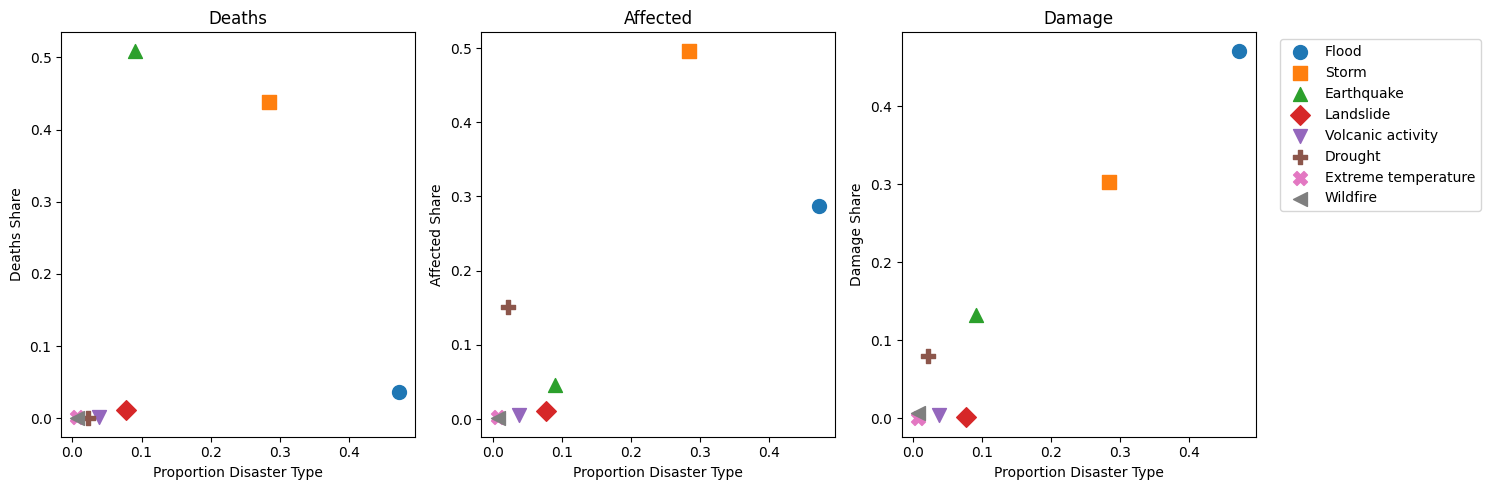

In [9]:
markers = ["o", "s", "^", "D", "v", "P", "X", "<"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

y_vars = ["Deaths_Share", "Affected_Share", "Damage_Share"]
titles = ["Deaths", "Affected", "Damage"]


for i, ax in enumerate(axes):
    for j, (_, row) in enumerate(disaster_type.iterrows()):
        ax.scatter(
            row["Proportion"]/ 100,
            row[y_vars[i]]/ 100,
            marker=markers[j % len(markers)],
            s = 100,
            label=row["Disaster Type"]
        )
    
    ax.set_xlabel("Proportion Disaster Type")
    ax.set_ylabel(f"{titles[i]} Share")
    ax.set_title(titles[i])

axes[2].legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

# Your code

Comparing this plot to the figure created in 1.2, we observe that storms are no longer the disaster type associated with the largest death and damage shares. Now, earthquakes have the highest death share and floods have the highest damage share. Which events are now considered in the analysis that were excluded before?

### 2.3 Standardization (2000-2024)

In [10]:
disaster_type["Count_std"] = (
    (disaster_type["Count"] - disaster_type["Count"].min()) /
    (disaster_type["Count"].max() - disaster_type["Count"].min())
)

disaster_type["Damage_std"] = (
    (disaster_type["Total_Damage"] - disaster_type["Total_Damage"].min()) /
    (disaster_type["Total_Damage"].max() - disaster_type["Total_Damage"].min())
)

disaster_type["Deaths_std"] = (
    (disaster_type["Total_Deaths"] - disaster_type["Total_Deaths"].min()) /
    (disaster_type["Total_Deaths"].max() - disaster_type["Total_Deaths"].min())
)

disaster_type["Affected_std"] = (
    (disaster_type["Total_Affected"] - disaster_type["Total_Affected"].min()) /
    (disaster_type["Total_Affected"].max() - disaster_type["Total_Affected"].min())
)

### 2.4 "Risk" Classification (2000-2024)

<img src="eval_matrix.png" width="500">

**Figure 1:** "Risk" classification matrix based on impact and event occurrence.

In [11]:
print(disaster_type[["Disaster Type", "Count_std", "Deaths_std", "Affected_std", "Damage_std"]])

         Disaster Type  Count_std  Deaths_std  Affected_std  Damage_std
3                Flood   1.000000    0.070591      0.578045    1.000000
5                Storm   0.595925    0.861729      1.000000    0.642633
1           Earthquake   0.179966    1.000000      0.091808    0.281371
4            Landslide   0.151104    0.023623      0.019085    0.004579
6    Volcanic activity   0.066214    0.004810      0.007889    0.007791
0              Drought   0.032258    0.000000      0.302646    0.168754
2  Extreme temperature   0.000000    0.002300      0.002850    0.000000
7             Wildfire   0.000000    0.000042      0.000000    0.015528


Classify each of the eight event types as high, relatively high or moderate for *the same* impact variable as in 1.4.

Impact variable: ________________
- Drought: ________________ 
- Earthquake: ________________
- Extreme temperature: ________________
- Flood: ________________
- Landslide: ________________
- Storm: ________________
- Volcanic activity: ________________
- Wildfire: ________________

What changed compared to exercise 1.4?

## 3. Analysis of Disaster Type, Global (2000-2024)

We repeat 2.1 - 2.4 for the *global* dataset (`global_events.csv`, retrieved on March 18th from https://public.emdat.be), which includes observations for all disaster types and all countries from 2000 to 2024 (inclusive).

In [13]:
# Load data on global natural disasters (2000-2024)
global_events = pd.read_csv("global_events.csv")
global_events = global_events.rename(columns={"Total Damage, Adjusted ('000 US$)": "Total Damage"})
global_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9382 entries, 0 to 9381
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Disaster Subgroup  9382 non-null   object 
 1   Disaster Type      9382 non-null   object 
 2   Disaster Subtype   9382 non-null   object 
 3   Country            9382 non-null   object 
 4   Start Year         9382 non-null   int64  
 5   Start Month        9333 non-null   float64
 6   Start Day          8313 non-null   float64
 7   End Year           9382 non-null   int64  
 8   End Month          9227 non-null   float64
 9   End Day            8304 non-null   float64
 10  Total Damage       3198 non-null   float64
 11  Total Deaths       6624 non-null   float64
 12  Total Affected     7508 non-null   float64
dtypes: float64(7), int64(2), object(4)
memory usage: 953.0+ KB


### 3.1 Proportion and Impact Shares of Disaster Types, Global (2000-2024)

In [14]:
# Group the data global_events by disaster type
disaster_type = (
    global_events.groupby("Disaster Type")
    .agg(
        Count=("Disaster Type", "size"),
        Total_Damage=("Total Damage", "sum"),
        Total_Deaths=("Total Deaths", "sum"),
        Total_Affected=("Total Affected", "sum")
    )
    .reset_index()
)

disaster_type["Proportion"] = 100 * disaster_type["Count"] / disaster_type["Count"].sum()
disaster_type = disaster_type.sort_values(by="Count", ascending=False)


# Calculate percentages for the four variables
disaster_type["Damage_Share"] = (
    100 * disaster_type["Total_Damage"] / disaster_type["Total_Damage"].sum()
)

disaster_type["Deaths_Share"] = (
    100 * disaster_type["Total_Deaths"] / disaster_type["Total_Deaths"].sum()
)

disaster_type["Affected_Share"] = (
    100 * disaster_type["Total_Affected"] / disaster_type["Total_Affected"].sum()
)

disaster_type = disaster_type.loc[:, 
                                  ['Disaster Type', 'Count', 'Proportion',
                                    'Total_Damage', 'Damage_Share',
                                    'Total_Deaths', 'Deaths_Share',
                                    'Total_Affected', 'Affected_Share']
                                  ]
disaster_type

,Disaster Type,Count,Proportion,Total_Damage,Damage_Share,Total_Deaths,Deaths_Share,Total_Affected,Affected_Share
3,Flood,4128,43.999147,1.065637e+09,21.898403,136405.0,8.785257,1.855552e+09,39.170483
5,Storm,2673,28.490727,2.403344e+09,49.387727,223090.0,14.368264,8.754461e+08,18.480565
1,Earthquake,664,7.077382,8.971483e+08,18.436027,790018.0,50.881649,1.530731e+08,3.231356
2,Extreme temperature,567,6.043488,7.483544e+07,1.537837,352756.0,22.719491,1.339102e+08,2.826828
4,Landslide,489,5.212108,7.537963e+06,0.154902,22244.0,1.432640,8.817404e+06,0.186134
0,Drought,416,4.434023,2.617888e+08,5.379652,24170.0,1.556685,1.688789e+09,35.650145
7,Wildfire,316,3.368152,1.516694e+08,3.116743,2231.0,0.143689,1.500590e+07,0.316773
6,Volcanic activity,129,1.374973,4.316779e+06,0.088708,1744.0,0.112324,6.523758e+06,0.137716


### 3.2 Scatter Plot, Global (2000-2024)

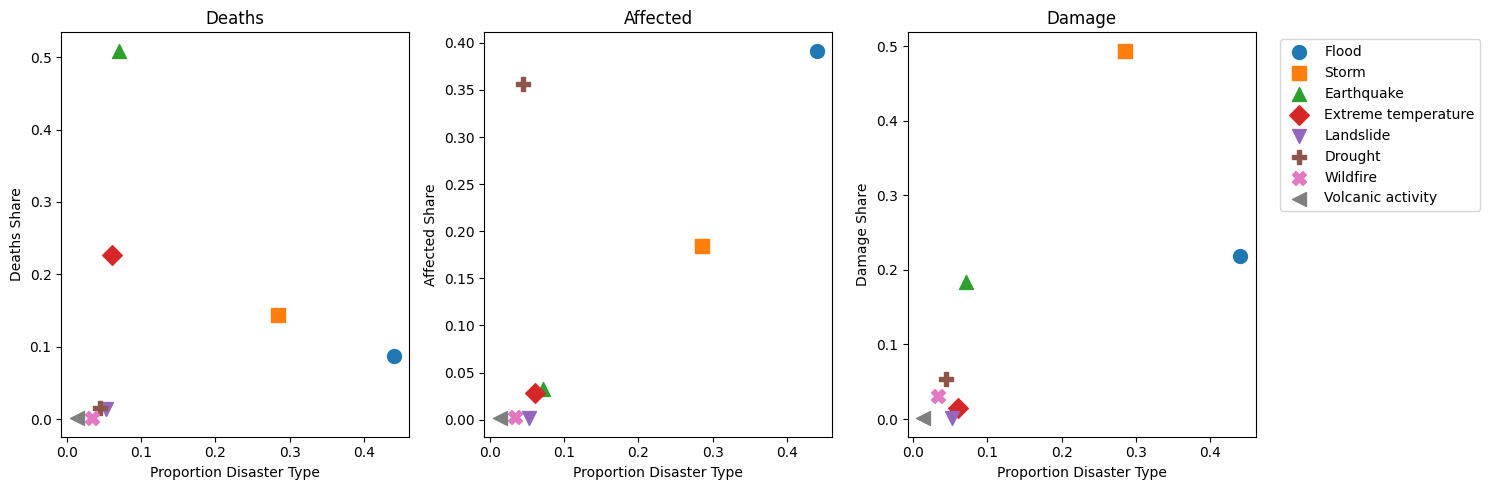

In [15]:
markers = ["o", "s", "^", "D", "v", "P", "X", "<"] 

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

y_vars = ["Deaths_Share", "Affected_Share", "Damage_Share"]
titles = ["Deaths", "Affected", "Damage"]


for i, ax in enumerate(axes):
    for j, (_, row) in enumerate(disaster_type.iterrows()):
        ax.scatter(
            row["Proportion"]/ 100,
            row[y_vars[i]]/ 100,
            marker=markers[j % len(markers)],
            s = 100,
            label=row["Disaster Type"]
        )
    
    ax.set_xlabel("Proportion Disaster Type")
    ax.set_ylabel(f"{titles[i]} Share")
    ax.set_title(titles[i])

axes[2].legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

Comparing this plot to the figures created in 1.2 and 2.2, we observe that earthquakes are associated with the highest death share as in 2.2, yet, storms are globally associated with the largest damage share. Interestingly, floods have the highest affected shares globally, closely followed by droughts. This implies that whilst floods and storms seem to cause the most damage in Southeast Asia, this is only partially true on a global level.

### 3.3 Standardization, Global (2000-2024)

In [16]:
disaster_type["Count_std"] = (
    (disaster_type["Count"] - disaster_type["Count"].min()) /
    (disaster_type["Count"].max() - disaster_type["Count"].min())
)

disaster_type["Damage_std"] = (
    (disaster_type["Total_Damage"] - disaster_type["Total_Damage"].min()) /
    (disaster_type["Total_Damage"].max() - disaster_type["Total_Damage"].min())
)

disaster_type["Deaths_std"] = (
    (disaster_type["Total_Deaths"] - disaster_type["Total_Deaths"].min()) /
    (disaster_type["Total_Deaths"].max() - disaster_type["Total_Deaths"].min())
)

disaster_type["Affected_std"] = (
    (disaster_type["Total_Affected"] - disaster_type["Total_Affected"].min()) /
    (disaster_type["Total_Affected"].max() - disaster_type["Total_Affected"].min())
)

### 3.4 "Risk" Classification, Global (2000-2024)

<img src="eval_matrix.png" width="500">

**Figure 1:** "Risk" classification matrix based on impact and event occurrence.

In [17]:
print(disaster_type[["Disaster Type", "Count_std", "Deaths_std", "Affected_std", "Damage_std"]])

         Disaster Type  Count_std  Deaths_std  Affected_std  Damage_std
3                Flood   1.000000    0.170830      1.000000    0.442396
5                Storm   0.636159    0.280798      0.469935    1.000000
1           Earthquake   0.133783    1.000000      0.079258    0.372164
2  Extreme temperature   0.109527    0.445292      0.068894    0.029395
4            Landslide   0.090023    0.026006      0.001240    0.001343
0              Drought   0.071768    0.028449      0.909811    0.107324
7             Wildfire   0.046762    0.000618      0.004587    0.061422
6    Volcanic activity   0.000000    0.000000      0.000000    0.000000


Classify each of the eight event types as high, relatively high or moderate for *the same* impact variable as in 1.4.

Impact variable: ________________
- Drought: ________________ 
- Earthquake: ________________
- Extreme temperature: ________________
- Flood: ________________
- Landslide: ________________
- Storm: ________________
- Volcanic activity: ________________
- Wildfire: ________________

What changed compared to exercise 1.4?